In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration visuelle
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

# 1. Chargement des données (assurez-vous du bon chemin vers votre fichier)
df = pd.read_csv('Données_test/diabetes_prediction_dataset.csv')
print(f"Taille originale du dataset : {df.shape}")

# 2. Nettoyage : suppression des doublons
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Taille après suppression des doublons : {df_clean.shape}")

# 3. Aperçu rapide de la variable cible
print("\nRépartition de la variable cible (Diabète) :")
print(df_clean['diabetes'].value_counts(normalize=True) * 100)

df_clean.head()

Taille originale du dataset : (100000, 9)
Taille après suppression des doublons : (96146, 9)

Répartition de la variable cible (Diabète) :
diabetes
0    91.178
1     8.822
Name: proportion, dtype: float64


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# 1. Séparation des variables explicatives (X) et de la cible (y)
X = df_clean.drop(columns=['diabetes'])
y = df_clean['diabetes']

# 2. Définition du prétraitement (Feature Engineering)
cat_cols = ['gender', 'smoking_history']
num_cols = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

# 3. Séparation Train / Test (80% pour l'entraînement, 20% pour le test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Données d'entraînement : {X_train.shape[0]} lignes")
print(f"Données de test : {X_test.shape[0]} lignes")

Données d'entraînement : 76916 lignes
Données de test : 19230 lignes


In [3]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

# 1. Création et entraînement du modèle "naïf"
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

# 2. Prédictions sur le jeu de test
y_pred_dummy = dummy.predict(X_test)

# 3. Évaluation des performances
print(f"Accuracy (Exactitude) : {accuracy_score(y_test, y_pred_dummy):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred_dummy):.3f}")


Accuracy (Exactitude) : 0.912
F1-score : 0.000


Rapport de classification (Régression Logistique) :
                precision    recall  f1-score   support

Non diabétique       0.99      0.88      0.93     17534
    Diabétique       0.43      0.88      0.57      1696

      accuracy                           0.88     19230
     macro avg       0.71      0.88      0.75     19230
  weighted avg       0.94      0.88      0.90     19230

Score AUC-ROC : 0.960


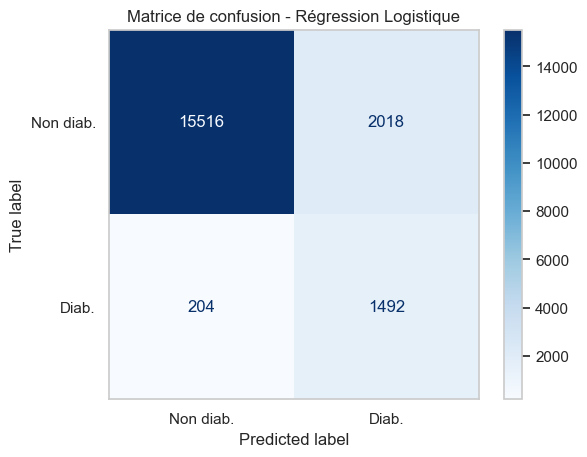

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Création du Pipeline (Prétraitement + Modèle)
logreg = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# 2. Entraînement du modèle
logreg.fit(X_train, y_train)

# 3. Prédictions sur le jeu de test
y_pred_lr = logreg.predict(X_test)
y_proba_lr = logreg.predict_proba(X_test)[:, 1] # Probabilités pour l'AUC

# 4. Affichage des résultats
print("Rapport de classification (Régression Logistique) :")
print(classification_report(y_test, y_pred_lr, target_names=['Non diabétique', 'Diabétique']))
print(f"Score AUC-ROC : {roc_auc_score(y_test, y_proba_lr):.3f}")

# 5. Affichage de la matrice de confusion
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non diab.', 'Diab.'])
disp.plot(cmap='Blues')
plt.title("Matrice de confusion - Régression Logistique")
plt.grid(False)
plt.show()

Rapport de classification (Random Forest équilibré) :
                precision    recall  f1-score   support

Non diabétique       0.99      0.91      0.95     17534
    Diabétique       0.49      0.89      0.63      1696

      accuracy                           0.91     19230
     macro avg       0.74      0.90      0.79     19230
  weighted avg       0.94      0.91      0.92     19230

Score AUC-ROC : 0.974


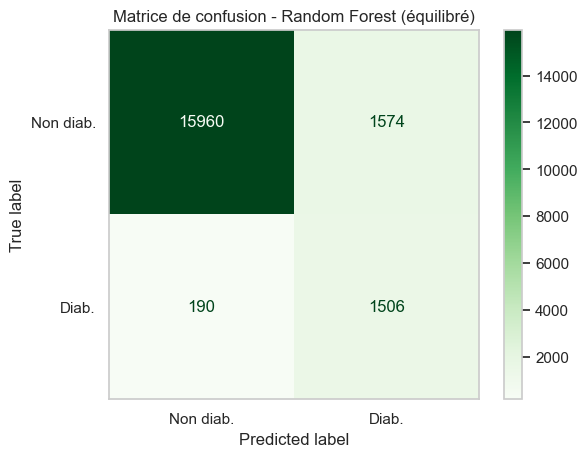

In [5]:
from sklearn.ensemble import RandomForestClassifier

# 1. Création du Pipeline pour le Random Forest équilibré
rf_balanced = Pipeline([
    ('prep', preprocess),
    # n_jobs=-1 permet d'utiliser tous les coeurs de l'ordinateur pour aller plus vite
    ('clf', RandomForestClassifier(n_estimators=300, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1))
])

# 2. Entraînement
rf_balanced.fit(X_train, y_train)

# 3. Prédictions
y_pred_rfb = rf_balanced.predict(X_test)
y_proba_rfb = rf_balanced.predict_proba(X_test)[:, 1]

# 4. Résultats
print("Rapport de classification (Random Forest équilibré) :")
print(classification_report(y_test, y_pred_rfb, target_names=['Non diabétique', 'Diabétique']))
print(f"Score AUC-ROC : {roc_auc_score(y_test, y_proba_rfb):.3f}")

# 5. Affichage de la matrice
cm_rf = confusion_matrix(y_test, y_pred_rfb)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Non diab.', 'Diab.'])
disp_rf.plot(cmap='Greens') # On change de couleur pour bien différencier les modèles
plt.title("Matrice de confusion - Random Forest (équilibré)")
plt.grid(False)
plt.show()